In [ ]:
###
    # This code plot the relationships between historical and future soil water content(liquid + frozen) across CMIP6 models. 
    # 1. Read soil water content data.
    # 2. Calculate water density (kg/m³) and interpolate onto a uniform vertical grid.
    # 3. Mask grid cells within permafrost regions, then calculate multi-year mean and area-weighted average within the region.
    # 4. Calculate total water content in the upper 1.6 m, 2.4 m, and 3.2 m.
    # 5. Reconstruct the vertical distribution of soil water for models that only provide bulk soil-column water content based on the above water content vertical profile.
    # 6. Plot scatter plots.
    # 7. Output: Figure S11.
###

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import glob
from scipy.stats import linregress
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import os
warnings.filterwarnings('ignore')

In [3]:
def area_weight_mean(data2D, lat, lon):
    """
    Calculate the area-weighted mean of 2D data, accounting for grid cell areas.
    
    Parameters:
    data2D: ndarray
        Variable for area-weighted averaging, with shape [lat, lon].
    lat: ndarray
        Latitude array, 1D, in degrees.
    lon: ndarray
        Longitude array, 1D, in degrees.
    
    Returns:
    float
        Area-weighted mean of the data.
    """
    # Convert latitude to radians
    rad = np.pi / 180.0
    lat_rad = lat * rad

    # Calculate latitude and longitude resolution
    re = 6371220.0  # Earth radius (in meters)
    dlon = np.abs(lon[1] - lon[0]) * rad  # Longitude resolution (in radians)
    dlat = np.abs(lat[1] - lat[0]) * rad  # Latitude resolution (in radians)

    # Calculate the area of each grid cell
    sin_lat1 = np.sin(lat_rad + dlat / 2)
    sin_lat2 = np.sin(lat_rad - dlat / 2)
    grid_areas = (re ** 2) * dlon * (sin_lat1 - sin_lat2)[:, np.newaxis]  # (lat, lon)

    # Calculate weighted mean
    valid_mask = ~np.isnan(data2D)  # Valid data mask
    weighted_sum = np.nansum(data2D * grid_areas * valid_mask)  # Sum of weighted values
    total_weight = np.nansum(grid_areas * valid_mask)  # Sum of weights

    # If total weight is 0 (all NaN), return NaN
    if total_weight == 0:
        return np.nan

    return weighted_sum / total_weight

In [ ]:
# Create an empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []

models = [
    "CESM2",
          "CESM2-FV2", 
          "CESM2-WACCM",
          "CNRM-CM6-1", 
          "CNRM-ESM2-1",
          "GFDL-ESM4", 
          "NorESM2-LM", "NorESM2-MM", 
          "TaiESM1"
          ]

# Data folder paths
data_folder = "../Data/cmip6_mrsfl/"
data_folder2 = "../Data/cmip6_mrsll/"
probability_file = "../Data/probability_lt_threshold_320.nc"

# Read probability threshold data
ds_prob = xr.open_dataset(probability_file)
ds_prob = ds_prob.sel(lon=slice(0, 186))

# Select grid points with probability_lt_threshold > 0
mask = ds_prob['probability_lt_threshold'] > 0
# Create grid for probability data
lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

# Loop through each model
for fi, model in enumerate(models):
        
    filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds = xr.open_dataset(filepath)
    ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds = ds.isel(time=year_mask)
    except:
        ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))

    filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
    # Read soil water content data
    ds2 = xr.open_dataset(filepath2)
    ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))

    try:
        # Select time period from 1982 to 2014
        years = np.array([dt.year for dt in ds2.time.values])
        year_mask = (years >= 1982) & (years <= 2014)
        ds2 = ds2.isel(time=year_mask)
    except:
        ds2 = ds2.sel(time=slice('1982-01-01', '2014-12-31'))

    total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

    try:
        depth = ds['depth']
        depth_bnds = ds['depth_bnds']
        thickness = np.empty(len(depth))
        for i in range(len(depth)):
            thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
    except:
        try:
            depth = ds['sdepth']
            depth_bnds = ds['sdepth_bounds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            zhalf_soil = ds['zhalf_soil'].values
            thickness = np.diff(zhalf_soil)         # Calculate thickness
    # Calculate water density (kg/m³)
    density_water_content = total / thickness[None, :, None, None]

    # Create new depth coordinate
    new_depths = np.arange(0.1, 10.1, 0.1)

    # Interpolation
    try:
        density_water_content_interp = density_water_content.interp(
            depth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    except:
        density_water_content_interp = density_water_content.interp(
            sdepth=new_depths, 
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )
    # Remove negative values
    density_water_content_interp = density_water_content_interp.clip(min=0)

    # Create grid for soil data
    lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
    
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
    
    # Interpolate mask to soil data grid
    mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                            mask.values.ravel(),
                            (lon_soil.ravel(), lat_soil.ravel()), 
                            method='nearest')
    
    mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

    # Create mask array with same dimensions as soil data
    mask_da = xr.DataArray(mask_interp, 
                            coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                            dims=['lat', 'lon'])

    # Apply mask to filter data
    density_water_masked = density_water_content_interp.where(mask_da, drop=False)

    # Apply land mask
    try:
        sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
    except:
        sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']

    land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
    if np.nanmax(land_mask_aligned) == 100:
        land_mask = land_mask_aligned > 50
    else:
        land_mask = land_mask_aligned > 0.5

    density_water_masked = density_water_masked.where(land_mask)
    # Calculate multi-year mean
    mean_yearly_range = density_water_masked.mean(dim='time')

    # ===============================
    # Area weighting (per depth level)
    # ===============================
    lat = mean_yearly_range.lat.values
    lon = mean_yearly_range.lon.values

    depth_profile_weighted = np.zeros(len(new_depths))

    for i in range(len(new_depths)):
        data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
        depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

    depth_profiles_all_models.append(depth_profile_weighted)

In [5]:
area_weighted_means16_total2 = []
area_weighted_means24_total2 = []
area_weighted_means32_total2 = []
for k,model in enumerate(models):
    print(model)
    print(np.sum(depth_profiles_all_models[k][2:16])*0.1)
    area_weighted_means16_total2.append(np.sum(depth_profiles_all_models[k][2:16])*0.1)
    area_weighted_means24_total2.append(np.sum(depth_profiles_all_models[k][2:24])*0.1)
    area_weighted_means32_total2.append(np.sum(depth_profiles_all_models[k][2:32])*0.1)

CESM2
432.7980789065439
CESM2-FV2
479.04238242178457
CESM2-WACCM
438.515147680308
CNRM-CM6-1
457.2834941008627
CNRM-ESM2-1
459.26157064888184
GFDL-ESM4
527.1454441108378
NorESM2-LM
470.3938474313069
NorESM2-MM
431.70804405548665
TaiESM1
431.3316777834496


In [6]:
model_year = pd.read_csv("../Data/Tas_data/years_reaching_three_warming_thresholds_ssp585.csv") # Table S2 # SSP5-8.5
model_year = model_year.iloc[:,1:]
model_year

,model,1.5,2,3
0,CESM2,"[2016,2035]","[2026,2045]","[2045,2064]"
1,CESM2-FV2,"[2013,2032]","[2027,2046]","[2050,2069]"
2,CESM2-WACCM,"[2011,2030]","[2024,2043]","[2044,2063]"
3,CNRM-CM6-1-HR,"[2009,2028]","[2020,2039]","[2042,2061]"
4,CNRM-CM6-1,"[2019,2038]","[2031,2050]","[2049,2068]"
5,CNRM-ESM2-1,"[2023,2042]","[2036,2055]","[2055,2074]"
6,E3SM-1-1,"[2016,2035]","[2023,2042]","[2037,2056]"
7,FGOALS-f3-L,"[2012,2031]","[2027,2046]","[2050,2069]"
8,FGOALS-g3,"[2018,2037]","[2037,2056]","[2063,2082]"
9,GFDL-CM4,"[2020,2039]","[2032,2051]","[2050,2069]"


In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []
model_water_16 = pd.DataFrame({'model': models, 'his': area_weighted_means16_total2, '1.5': '/', '2': '/', '3': '/'})
model_water_24 = pd.DataFrame({'model': models, 'his': area_weighted_means24_total2, '1.5': '/', '2': '/', '3': '/'})
model_water_32 = pd.DataFrame({'model': models, 'his': area_weighted_means32_total2, '1.5': '/', '2': '/', '3': '/'})

# Data folder paths
data_folder = "../Data/cmip6_mrsfl_ssp585/"
data_folder2 = "../Data/cmip6_mrsll_ssp585/"

# Loop through each model
for idx, model in enumerate(models):

    for threshold in ['1.5', '2', '3']:
        filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
        # Read soil ice content data
        ds = xr.open_dataset(filepath)
        ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

        filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
        # Read soil water content data
        ds2 = xr.open_dataset(filepath2)
        ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))
        time_period = model_year.loc[model_year['model'] == model, threshold].values[0]
        if time_period != '/':
            start, end = map(int, (time_period[1:5], time_period[6:10]))
        try:
            # Select time period from start to end year
            years = np.array([dt.year for dt in ds.time.values])
            year_mask = (years >= start) & (years <= end)
            ds = ds.isel(time=year_mask)
        except:
            ds = ds.sel(time=slice(f'{start}-01-01', f'{end}-12-31'))

        try:
            # Select time period from start to end year
            years = np.array([dt.year for dt in ds2.time.values])
            year_mask = (years >= start) & (years <= end)
            ds2 = ds2.isel(time=year_mask)
        except:
            ds2 = ds2.sel(time=slice(f'{start}-01-01', f'{end}-12-31'))

        total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

        try:
            depth = ds['depth']
            depth_bnds = ds['depth_bnds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            try:
                depth = ds['sdepth']
                depth_bnds = ds['sdepth_bounds']
                thickness = np.empty(len(depth))
                for i in range(len(depth)):
                    thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
            except:
                zhalf_soil = ds['zhalf_soil'].values
                thickness = np.diff(zhalf_soil)         # Calculate thickness
        # Calculate water density (kg/m³)
        density_water_content = total / thickness[None, :, None, None]

        # Create new depth coordinate
        new_depths = np.arange(0.1, 10.1, 0.1)

        # Interpolation
        try:
            density_water_content_interp = density_water_content.interp(
                depth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        except:
            density_water_content_interp = density_water_content.interp(
                sdepth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        # Remove negative values
        density_water_content_interp = density_water_content_interp.clip(min=0)

        # Create grid for soil data
        lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
        
        # Create grid for probability data
        lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
        
        # Interpolate mask to soil data grid
        mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                                mask.values.ravel(),
                                (lon_soil.ravel(), lat_soil.ravel()), 
                                method='nearest')
        
        mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

        # Create mask array with same dimensions as soil data
        mask_da = xr.DataArray(mask_interp, 
                                coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                                dims=['lat', 'lon'])

        # Apply mask to filter data
        density_water_masked = density_water_content_interp.where(mask_da, drop=False)

        # Apply land mask
        try:
            sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
        except:
            sftlf = xr.open_dataset(glob.glob(f'../Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']

        land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
        if np.nanmax(land_mask_aligned) == 100:
            land_mask = land_mask_aligned > 50
        else:
            land_mask = land_mask_aligned > 0.5

        density_water_masked = density_water_masked.where(land_mask)
        # Calculate multi-year mean
        mean_yearly_range = density_water_masked.mean(dim='time')

        # ===============================
        # Area weighting (per depth level)
        # ===============================
        lat = mean_yearly_range.lat.values
        lon = mean_yearly_range.lon.values

        depth_profile_weighted = np.zeros(len(new_depths))

        for i in range(len(new_depths)):
            data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
            depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)
        
        model_water_16.at[idx, threshold] = np.sum(depth_profile_weighted[2:16])*0.1
        model_water_24.at[idx, threshold] = np.sum(depth_profile_weighted[2:24])*0.1
        model_water_32.at[idx, threshold] = np.sum(depth_profile_weighted[2:32])*0.1

In [ ]:
dz = 0.1  # m

# ===============================
# Define fraction calculation function
# ===============================
def calc_all_fractions(profile, total_depth_m):

    n_total = int(total_depth_m / dz)
    n_total = min(n_total, len(profile))

    total = np.sum(profile[:n_total] * dz)

    if total == 0:
        return np.nan, np.nan, np.nan

    f_02_16 = np.sum(profile[2:16] * dz) / total
    f_02_24 = np.sum(profile[2:24] * dz) / total
    f_02_32 = np.sum(profile[2:32] * dz) / total

    return f_02_16, f_02_24, f_02_32

In [ ]:
def cal_water_profile(models, data_folder, data_folder2, startyear, endyear, depth_profiles_all_models):

    # Data folder path
    probability_file = "/home/wangjx/Code/整理最终代码/code/Data/Probability_pf/probability_lt_threshold_320.nc"

    # Read probability threshold data
    ds_prob = xr.open_dataset(probability_file)
    ds_prob = ds_prob.sel(lon=slice(0, 186))
    # Select grid points with probability_lt_threshold > 0
    mask = ds_prob['probability_lt_threshold'] > 0
    # Create grid for probability data
    lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)

    # Loop through each model
    for fi, model in enumerate(models):
        #print(f"Processing model: {model}")
            
        filepath = glob.glob(data_folder+f"mrsfl_Emon_{model}_*.nc")[0]        
        # Read soil water content data
        ds = xr.open_dataset(filepath)
        ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))

        try:
            # Select time period from startyear to endyear
            years = np.array([dt.year for dt in ds.time.values])
            year_mask = (years >= startyear) & (years <= endyear)
            ds = ds.isel(time=year_mask)
        except:
            ds = ds.sel(time=slice(f'{startyear}-01-01', f'{endyear}-12-31'))

        filepath2 = glob.glob(data_folder2+f"mrsll_Emon_{model}_*.nc")[0]        
        # Read soil water content data
        ds2 = xr.open_dataset(filepath2)
        ds2 = ds2.sel(lat=slice(45, 77.3), lon=slice(0, 186))

        try:
            # Select time period from startyear to endyear
            years = np.array([dt.year for dt in ds2.time.values])
            year_mask = (years >= startyear) & (years <= endyear)
            ds2 = ds2.isel(time=year_mask)
        except:
            ds2 = ds2.sel(time=slice(f'{startyear}-01-01', f'{endyear}-12-31'))

        total = (ds['mrsfl'] + ds2['mrsll'])  # shape: (time, depth, lat, lon)

        try:
            depth = ds['depth']
            depth_bnds = ds['depth_bnds']
            thickness = np.empty(len(depth))
            for i in range(len(depth)):
                thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
        except:
            try:
                depth = ds['sdepth']
                depth_bnds = ds['sdepth_bounds']
                thickness = np.empty(len(depth))
                for i in range(len(depth)):
                    thickness[i] = depth_bnds.values[i,1]-depth_bnds.values[i,0]         # Calculate thickness
            except:
                zhalf_soil = ds['zhalf_soil'].values
                thickness = np.diff(zhalf_soil)         # Calculate thickness
        # Calculate water density (kg/m³)
        density_water_content = total / thickness[None, :, None, None]

        # Create new depth coordinate
        new_depths = np.arange(0.1, 10.1, 0.1)

        # Interpolation
        try:
            density_water_content_interp = density_water_content.interp(
                depth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        except:
            density_water_content_interp = density_water_content.interp(
                sdepth=new_depths, 
                method='linear',
                kwargs={'fill_value': 'extrapolate'}
            )
        # Remove negative values
        density_water_content_interp = density_water_content_interp.clip(min=0)

        # Create grid for soil data
        lon_soil, lat_soil = np.meshgrid(density_water_content_interp.lon.values, density_water_content_interp.lat.values)
        
        # Create grid for probability data
        lon_prob, lat_prob = np.meshgrid(ds_prob.lon.values, ds_prob.lat.values)
        
        # Interpolate mask to soil data grid
        mask_interp = griddata((lon_prob.ravel(), lat_prob.ravel()), 
                                mask.values.ravel(),
                                (lon_soil.ravel(), lat_soil.ravel()), 
                                method='nearest')
        
        mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

        # Create mask array with same dimensions as soil data
        mask_da = xr.DataArray(mask_interp, 
                                coords={'lat': density_water_content_interp.lat, 'lon': density_water_content_interp.lon},
                                dims=['lat', 'lon'])

        # Apply mask to filter data
        density_water_masked = density_water_content_interp.where(mask_da, drop=False)

        # Apply land mask
        try:
            sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
        except:
            sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']

        land_mask_aligned = sftlf.reindex_like(density_water_masked, method='nearest', tolerance=0.01)
        if np.nanmax(land_mask_aligned) == 100:
            land_mask = land_mask_aligned > 50
        else:
            land_mask = land_mask_aligned > 0.5

        density_water_masked = density_water_masked.where(land_mask)
        # Calculate multi-year mean
        mean_yearly_range = density_water_masked.mean(dim='time')

        # ===============================
        # Area weighting (per depth level)
        # ===============================
        lat = mean_yearly_range.lat.values
        lon = mean_yearly_range.lon.values

        depth_profile_weighted = np.zeros(len(new_depths))

        for i in range(len(new_depths)):
            data2D = mean_yearly_range[i,:,:].values  # (lat, lon)
            depth_profile_weighted[i] = area_weight_mean(data2D, lat, lon)

        depth_profiles_all_models.append(depth_profile_weighted)
    return depth_profiles_all_models

In [ ]:
def cal_his_fur_water(models,target_models,depth_profiles_all_models,data_folder3,data_folder4,results,results_1_5,results_2,results_3):
    for k,threshold in enumerate(['1.5', '2', '3']):
        depth_profiles_all_models_fut = []
        for model in models:
            time_period = model_year.loc[model_year['model'] == model, threshold].values[0]
            if time_period != '/':
                start, end = map(int, (time_period[1:5], time_period[6:10]))
            depth_profiles_all_models_fut = cal_water_profile(models,data_folder3,data_folder4,start,end,depth_profiles_all_models_fut)

        mrso_folder_his = "/home/wangjx/Data/cmip6_mrso/"
        mrso_folder_fut = "/home/wangjx/Data/cmip6_mrso_ssp585/"

        for model in target_models:

            print(f"\n==== Processing {model} ====")

            # ---------------------------
            # 1. Read total soil column depth
            # ---------------------------
            if model in ["CESM2","FGOALS-g3","FGOALS-f3-L","E3SM-1-1"]:
                total_depth = 8.02999973297119
            else:
                tsl_file = glob.glob(f"/home/jidy/Data/tas-tsl-merge/tsl_{model}_*.nc")[0]
                ds_tsl = xr.open_dataset(tsl_file)
                total_depth = float(ds_tsl['depth'].values[-1])
                total_depth = np.round(total_depth, 1)

            print("Total depth:", total_depth)

            # ---------------------------
            # 2. Calculate fractions
            # ---------------------------
            f1_list, f2_list, f3_list = [], [], []

            for profile in depth_profiles_all_models:
                f1, f2, f3 = calc_all_fractions(profile, total_depth)
                f1_list.append(f1)
                f2_list.append(f2)
                f3_list.append(f3)

            frac_02_16 = np.nanmean(f1_list)
            frac_02_24 = np.nanmean(f2_list)
            frac_02_32 = np.nanmean(f3_list)

            print("Fractions:", frac_02_16, frac_02_24, frac_02_32)

            # ---------------------------
            # 3. Read mrso data
            # ---------------------------
            filepath = glob.glob(mrso_folder_his + f"mrso_Lmon_{model}_*.nc")[0]
            ds = xr.open_dataset(filepath)
            ds = ds.sel(lat=slice(45, 77.3), lon=slice(0, 186))
            try:
                years = np.array([dt.year for dt in ds.time.values])
                mask_time = (years >= 1982) & (years <= 2014)
                ds = ds.isel(time=mask_time)
            except:
                ds = ds.sel(time=slice('1982-01-01', '2014-12-31'))
            mrso = ds['mrso']  # (time, lat, lon)

            filepath_fut = glob.glob(mrso_folder_fut + f"mrso_Lmon_{model}_*.nc")[0]
            ds_fut = xr.open_dataset(filepath_fut)
            ds_fut = ds_fut.sel(lat=slice(45, 77.3), lon=slice(0, 186))
            try:
                years = np.array([dt.year for dt in ds_fut.time.values])
                mask_time = (years >= start) & (years <= end)
                ds_fut = ds_fut.isel(time=mask_time)
            except:
                ds_fut = ds_fut.sel(time=slice(f'{start}-01-01', f'{end}-12-31'))

            mrso_fut = ds_fut['mrso']  # (time, lat, lon)

            # ---------------------------
            # 4. Interpolate permafrost mask
            # ---------------------------

            lon_soil, lat_soil = np.meshgrid(mrso.lon.values, mrso.lat.values)

            mask_interp = griddata(
                (lon_prob.ravel(), lat_prob.ravel()),
                mask_pf.values.ravel(),
                (lon_soil.ravel(), lat_soil.ravel()),
                method='nearest'
            )

            mask_interp = mask_interp.reshape(lon_soil.shape).astype(bool)

            mask_da = xr.DataArray(mask_interp,
                                coords={'lat': mrso.lat, 'lon': mrso.lon},
                                dims=['lat', 'lon'])

            mrso = mrso.where(mask_da, drop=False)
            mrso_fut = mrso_fut.where(mask_da, drop=False)

            # ---------------------------
            # 5. Land mask
            # ---------------------------
            if model == 'FGOALS-f3-L':
                mrso = mrso
                mrso_fut = mrso_fut
            else:
                try:
                    sftlf = xr.open_dataset(glob.glob(f'/home/jidy/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
                except:
                    sftlf = xr.open_dataset(glob.glob(f'/home/wangjx/Data/cmip6-fx/sftlf_fx_{model}_*.nc')[0]).sel(lat=slice(45, 77.3), lon=slice(0, 186))['sftlf']
                # Align to mrso grid
                sftlf_aligned = sftlf.reindex_like(mrso, method='nearest', tolerance=0.01)
                land_mask = sftlf_aligned > 50 if np.nanmax(sftlf_aligned) == 100 else sftlf_aligned > 0.5

                mrso = mrso.where(land_mask)
                mrso_fut = mrso_fut.where(land_mask)
            # ---------------------------
            # 6. Time average
            # ---------------------------
            mrso_mean = mrso.mean(dim='time')
            mrso_fut_mean = mrso_fut.mean(dim='time')

            lat = mrso_mean.lat.values
            lon = mrso_mean.lon.values

            # ---------------------------
            # 7. Area-weighted mean
            # ---------------------------
            warea_mean = area_weight_mean(mrso_mean.values, lat, lon)
            warea_fut_mean = area_weight_mean(mrso_fut_mean.values, lat, lon)
            print("Area-weighted mean:", warea_mean)
            
            # ---------------------------
            # 8. Calculate layer water content
            # ---------------------------
            water_02_16 = warea_mean * frac_02_16
            water_02_24 = warea_mean * frac_02_24
            water_02_32 = warea_mean * frac_02_32

            print("Results (kg m-2):", water_02_16, water_02_24, water_02_32)

            results[model] = (water_02_16, water_02_24, water_02_32)

            # ---------------------------
            # Calculate future fractions
            # ---------------------------
            f1_fut_list, f2_fut_list, f3_fut_list = [], [], []

            for profile in depth_profiles_all_models_fut:
                f1, f2, f3 = calc_all_fractions(profile, total_depth)
                f1_fut_list.append(f1)
                f2_fut_list.append(f2)
                f3_fut_list.append(f3)

            frac_fut_02_16 = np.nanmean(f1_fut_list)
            frac_fut_02_24 = np.nanmean(f2_fut_list)
            frac_fut_02_32 = np.nanmean(f3_fut_list)

            print("Future fractions:", frac_fut_02_16, frac_fut_02_24, frac_fut_02_32)

            water_02_16_fut = warea_fut_mean * frac_fut_02_16
            water_02_24_fut = warea_fut_mean * frac_fut_02_24
            water_02_32_fut = warea_fut_mean * frac_fut_02_32

            print("Future results (kg m-2):", water_02_16_fut, water_02_24_fut, water_02_32_fut)
            if k==0:
                results_1_5[model] = (water_02_16_fut, water_02_24_fut, water_02_32_fut)
            elif k==1:
                results_2[model] = (water_02_16_fut, water_02_24_fut, water_02_32_fut)
            else:
                results_3[model] = (water_02_16_fut, water_02_24_fut, water_02_32_fut)
    
    return results, results_1_5, results_2, results_3

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []
models = ["CESM2","CESM2-FV2", "CESM2-WACCM", "NorESM2-LM", "NorESM2-MM"]
data_folder = "../Data/cmip6_mrsfl/"
data_folder2 = "../Data/cmip6_mrsll/"
depth_profiles_all_models = cal_water_profile(models, data_folder, data_folder2, 1982, 2014, depth_profiles_all_models)

data_folder3 = "../Data/cmip6_mrsfl_ssp585/"
data_folder4 = "/../Data/cmip6_mrsll_ssp585/"

results_1_5 = {}
results_2 = {}
results_3 = {}
results = {}

# ===============================
# Target models
# ===============================
target_models = ["MPI-ESM1-2-LR","MPI-ESM1-2-HR",
                    "FGOALS-g3","FGOALS-f3-L","E3SM-1-1"]

results, results_1_5, results_2, results_3 = cal_his_fur_water(models, target_models, depth_profiles_all_models, data_folder3, data_folder4, results, results_1_5, results_2, results_3)

# ===============================
# Final results
# ===============================
print("\n==== Final Results ====")
for m, v in results.items():
    print(m, v)

print("\n==== Future Results ====")
for m, v in results_3.items():
    print(m, v)


==== 处理 MPI-ESM1-2-LR ====
总深度: 7.0
fractions: 0.4326681661655324 0.5519342914026172 0.6379403548565904
warea_mean: 594.3766396779763
结果 (kg m-2): 257.16785070110143 328.0568494469326 379.176844434636
fractions: 0.426585782562047 0.5448225338856707 0.6310659562480225
未来结果 (kg m-2): 254.382154803328 324.88923874317754 376.3180216866353

==== 处理 MPI-ESM1-2-HR ====
总深度: 7.0
fractions: 0.4326681661655324 0.5519342914026172 0.6379403548565904
warea_mean: 576.1735492941809
结果 (kg m-2): 249.29195296619923 318.0099396546147 367.56435849571096
fractions: 0.426585782562047 0.5448225338856707 0.6310659562480225
未来结果 (kg m-2): 246.33106744368536 314.6066320668113 364.407715832243

==== 处理 FGOALS-g3 ====
总深度: 8.02999973297119
fractions: 0.41131392964468627 0.5247000924491318 0.6064654209727158
warea_mean: 1103.6484183919401
结果 (kg m-2): 453.94596791493177 579.0844271615891 669.32460266594
fractions: 0.40321097429852815 0.5149746487383826 0.5964949414101496
未来结果 (kg m-2): 447.8474418658764 571.9836

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []
models = ["CNRM-CM6-1", "CNRM-ESM2-1" ]
depth_profiles_all_models = cal_water_profile(models, data_folder, data_folder2, 1982, 2014, depth_profiles_all_models)

# ===============================
# Target models
# ===============================
target_models = ["CNRM-CM6-1-HR"]

results, results_1_5, results_2, results_3 = cal_his_fur_water(models, target_models, depth_profiles_all_models, data_folder3, data_folder4, results, results_1_5, results_2, results_3)

# ===============================
# Final results
# ===============================
print("\n==== Final Results ====")
for m, v in results.items():
    print(m, v)

print("\n==== Future Results ====")
for m, v in results_3.items():
    print(m, v)


==== 处理 CNRM-CM6-1-HR ====
总深度: 10.0
fractions: 0.12261425412536558 0.19956120683998352 0.28041039940045087
warea_mean: 4528.8102111335165
结果 (kg m-2): 555.2966861134755 903.7748312830452 1269.9254801127895
fractions: 0.1215913119256616 0.19658826562644788 0.27589389553429555
未来结果 (kg m-2): 545.9196182899839 882.6402909172856 1238.7060206300162

==== 处理 CNRM-CM6-1-HR ====
总深度: 10.0
fractions: 0.12261425412536558 0.19956120683998352 0.28041039940045087
warea_mean: 4528.8102111335165
结果 (kg m-2): 555.2966861134755 903.7748312830452 1269.9254801127895
fractions: 0.12169756241679619 0.1958721240749027 0.2743838783358057
未来结果 (kg m-2): 542.8847973066491 873.7726234173967 1224.0083795958387

==== 处理 CNRM-CM6-1-HR ====
总深度: 10.0
fractions: 0.12261425412536558 0.19956120683998352 0.28041039940045087
warea_mean: 4528.8102111335165
结果 (kg m-2): 555.2966861134755 903.7748312830452 1269.9254801127895
fractions: 0.12198911863087573 0.19459915222102353 0.2716221348129383
未来结果 (kg m-2): 535.22905121

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []
models = ["GFDL-ESM4"]
depth_profiles_all_models = cal_water_profile(models, data_folder, data_folder2, 1982, 2014, depth_profiles_all_models)

# ===============================
# Target models
# ===============================
target_models = ["GFDL-CM4"]

results, results_1_5, results_2, results_3 = cal_his_fur_water(models, target_models, depth_profiles_all_models, data_folder3, data_folder4, results, results_1_5, results_2, results_3)

# ===============================
# Final results
# ===============================
print("\n==== Final Results ====")
for m, v in results.items():
    print(m, v)

print("\n==== Future Results ====")
for m, v in results_3.items():
    print(m, v)


==== 处理 GFDL-CM4 ====
总深度: 8.8
fractions: 0.15010725507193665 0.24543283666550994 0.34097094488575797
warea_mean: 3816.560098787991
结果 (kg m-2): 572.8933602461448 936.7091713499356 1301.3361030970232
fractions: 0.1495772373175337 0.24416305654629328 0.3395972689006585
未来结果 (kg m-2): 571.3690088362933 932.6766967699715 1297.2251554784953

==== 处理 GFDL-CM4 ====
总深度: 8.8
fractions: 0.15010725507193665 0.24543283666550994 0.34097094488575797
warea_mean: 3816.560098787991
结果 (kg m-2): 572.8933602461448 936.7091713499356 1301.3361030970232
fractions: 0.1493740367405725 0.2435622811810234 0.33876490370266144
未来结果 (kg m-2): 570.6280404546883 930.4392535121931 1294.125521360868

==== 处理 GFDL-CM4 ====
总深度: 8.8
fractions: 0.15010725507193665 0.24543283666550994 0.34097094488575797
warea_mean: 3816.560098787991
结果 (kg m-2): 572.8933602461448 936.7091713499356 1301.3361030970232
fractions: 0.1493062182819113 0.24241240120175248 0.33658337545276384
未来结果 (kg m-2): 577.629248284463 937.8343024977959 

In [ ]:
# Create empty list to store area-weighted average of total water for each model
depth_profiles_all_models = []
models = ["CNRM-CM6-1", "CNRM-ESM2-1",
          "GFDL-ESM4"]
depth_profiles_all_models = cal_water_profile(models, data_folder, data_folder2, 1982, 2014, depth_profiles_all_models)

# ===============================
# Target models
# ===============================
target_models = ["MIROC-ES2L","MIROC6"]

results, results_1_5, results_2, results_3 = cal_his_fur_water(models, target_models, depth_profiles_all_models, data_folder3, data_folder4, results, results_1_5, results_2, results_3)

# ===============================
# Final results
# ===============================
print("\n==== Final Results ====")
for m, v in results.items():
    print(m, v)

print("\n==== Future Results ====")
for m, v in results_3.items():
    print(m, v)


==== 处理 MIROC-ES2L ====
总深度: 9.0
fractions: 0.14002041164190823 0.22825734749641913 0.3194628059193605
warea_mean: 5908.763734916229
结果 (kg m-2): 827.3475304577495 1348.718737115013 1887.6302422708989
fractions: 0.139334107658995 0.2258850858635605 0.31590412486374203
未来结果 (kg m-2): 820.7004739805418 1330.4997616740513 1860.7264894723291

==== 处理 MIROC6 ====
总深度: 9.0
fractions: 0.14002041164190823 0.22825734749641913 0.3194628059193605
warea_mean: 5912.30161628064
结果 (kg m-2): 827.8429060627345 1349.5262845310106 1888.7604637785835
fractions: 0.139334107658995 0.2258850858635605 0.31590412486374203
未来结果 (kg m-2): 823.7777300656493 1335.488534822905 1867.703373358697

==== 处理 MIROC-ES2L ====
总深度: 9.0
fractions: 0.14002041164190823 0.22825734749641913 0.3194628059193605
warea_mean: 5908.763734916229
结果 (kg m-2): 827.3475304577495 1348.718737115013 1887.6302422708989
fractions: 0.13942486656091413 0.2252877114458742 0.3147068532970274
未来结果 (kg m-2): 820.8219631358749 1326.3136350114398 1

In [15]:
models_mrso = ["CNRM-CM6-1-HR",
               "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","MIROC6",
               "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR"]
for model in models_mrso:
    model_water_16.loc[len(model_water_16)] = [model, results[model][0], results_1_5[model][0], results_2[model][0],results_3[model][0]]
    model_water_24.loc[len(model_water_24)] = [model, results[model][1], results_1_5[model][1], results_2[model][1],results_3[model][1]]
    model_water_32.loc[len(model_water_32)] = [model, results[model][2], results_1_5[model][2], results_2[model][2],results_3[model][2]]
model_water_16

,model,his,1.5,2,3
0,CESM2,432.798079,426.514634,425.314428,419.209787
1,CESM2-FV2,479.042382,470.121046,465.3467,459.795929
2,CESM2-WACCM,438.515148,433.309324,432.795088,427.972268
3,CNRM-CM6-1,457.283494,449.495596,444.339243,436.465743
4,CNRM-ESM2-1,459.261571,446.309969,440.142417,430.291792
5,GFDL-ESM4,527.145444,526.389103,525.829299,524.095942
6,NorESM2-LM,470.393847,458.619677,457.045255,441.130859
7,NorESM2-MM,431.708044,423.64309,420.711963,418.352106
8,TaiESM1,431.331678,435.041077,436.889531,440.59949
9,CNRM-CM6-1-HR,555.296686,545.919618,542.884797,535.229051


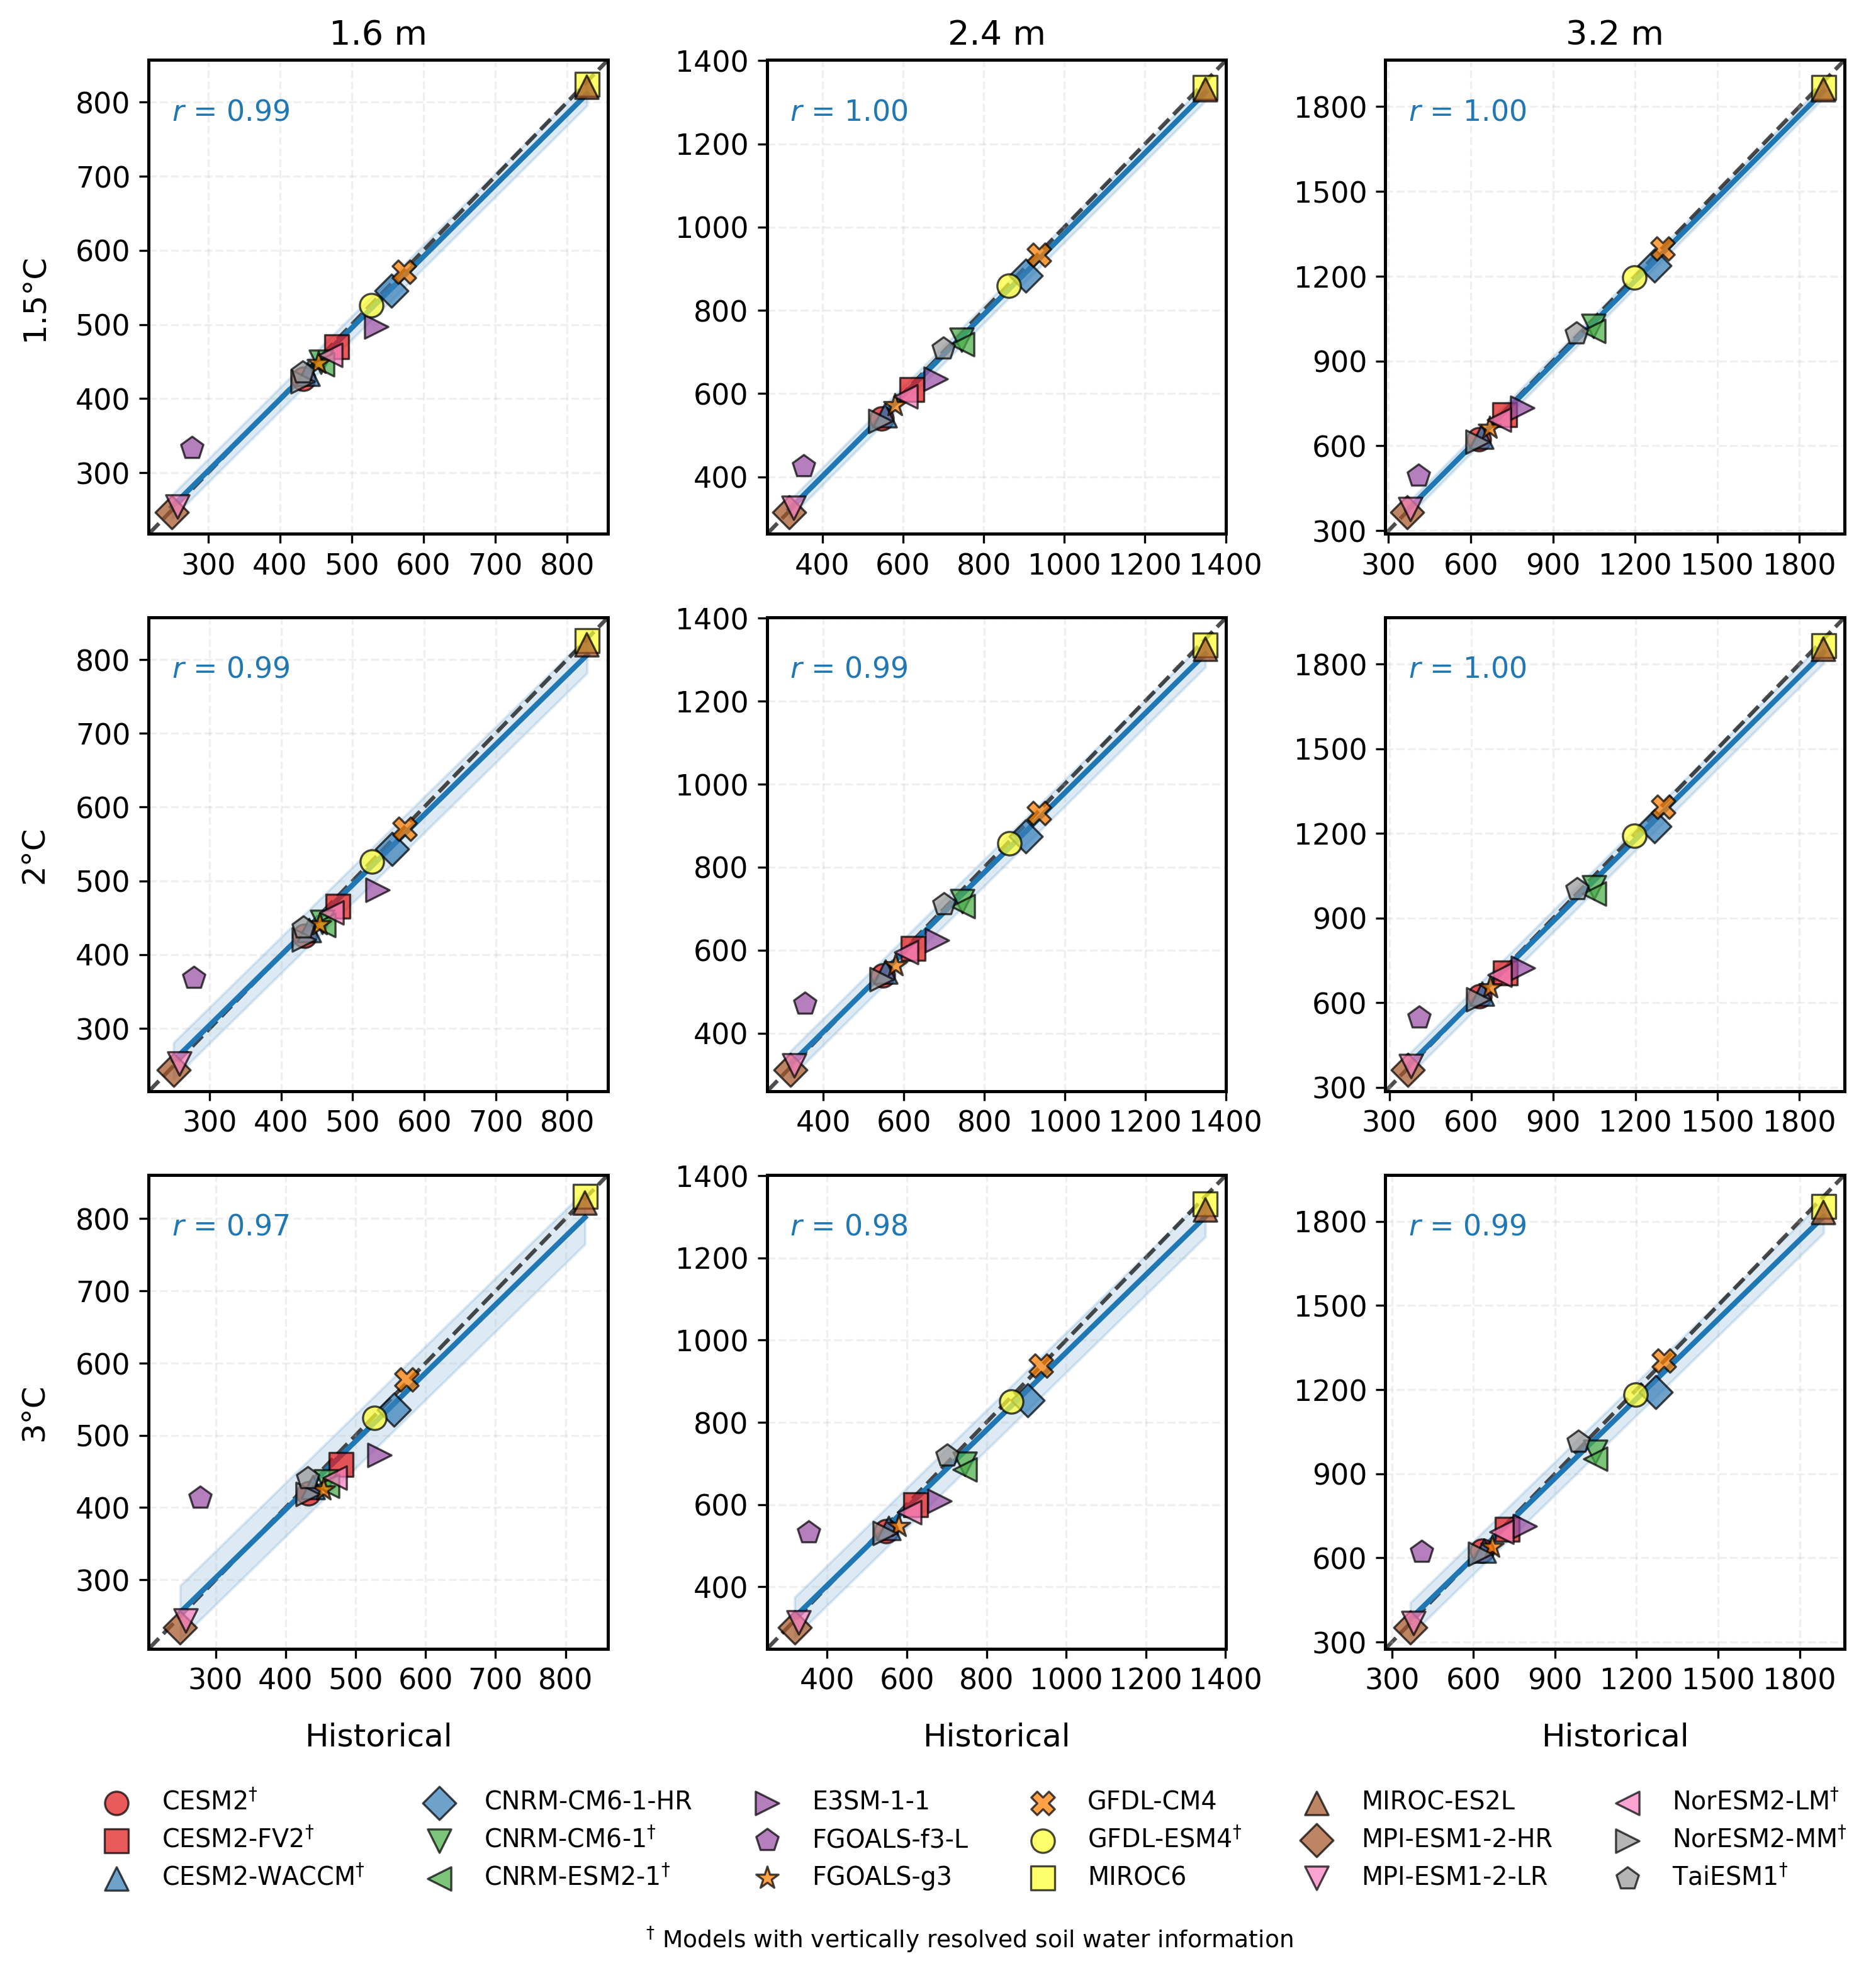

In [ ]:
# =============================
# Data
# =============================
# First sort the three dataframes according to the specified order
models_order = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
                "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6",
                "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]

# Sort each dataframe
model_water_16 = model_water_16.set_index('model').loc[models_order].reset_index()
model_water_24 = model_water_24.set_index('model').loc[models_order].reset_index()
model_water_32 = model_water_32.set_index('model').loc[models_order].reset_index()

dfs = [model_water_16, model_water_24, model_water_32]
titles = ['1.6 m', '2.4 m', '3.2 m']
tick_steps = [100, 200, 300]
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
colors = plt.cm.Set1(np.linspace(0, 1, len(models_order)))  # Generate color list using colormap

# Three scenarios
scenarios = ['1.5', '2', '3']
row_labels = ['1.5°C', '2°C', '3°C']

# Models requiring special marking (black edge outline)
layered_models = ["CESM2",
          "CESM2-FV2", 
          "CESM2-WACCM",
          "CNRM-CM6-1", 
          "CNRM-ESM2-1",
          "GFDL-ESM4", 
          "NorESM2-LM", 
          "NorESM2-MM", 
          "TaiESM1"
          ]

# =============================
# Style settings
# =============================
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.titlesize': 13
})

# =============================
# Create 3×3 subplots
# =============================
fig, axes = plt.subplots(3, 3, figsize=(10, 10), dpi=300)

# =============================
# Collect handles for legend
# =============================
legend_handles = []
legend_labels = []

# =============================
# Loop: rows (scenarios) × columns (depths)
# =============================
for row, (scen, row_lab) in enumerate(zip(scenarios, row_labels)):
    
    for col, (df, title) in enumerate(zip(dfs, titles)):
        
        ax = axes[row, col]
        
        x = np.asarray(df['his']).astype(float)
        y = np.asarray(df[scen]).astype(float)
        
        # Extract data for models with black edge outline
        layered_indices = [i for i, model in enumerate(df['model']) if model in layered_models]
        x_layered = x[layered_indices]
        y_layered = y[layered_indices]
        
        for i in range(len(x)):
            model_name = df['model'].iloc[i]
            if model_name in layered_models:
                #edge_color = 'white'
                #edge_width = 0.5
                edge_color = 'black'
                edge_width = 0.8
            else:
                edge_color = 'black'
                edge_width = 0.8
            
            scatter = ax.scatter(
                x[i], y[i],
                s=80,
                color=colors[i],  # Cycle through colors
                marker=markers[i % len(markers)],
                alpha=0.72,
                edgecolor=edge_color,
                linewidth=edge_width,
                zorder=3,
                label=df['model'].iloc[i] if row == 0 and col == 0 else ""  # Only add legend label on the first subplot
            )
            
            # Collect legend handles (only once on the first subplot)
            if row == 0 and col == 0 and i < len(df):
                legend_handles.append(scatter)
                # Add dagger symbol for layered models
                if model_name in layered_models:
                    legend_labels.append(model_name + r'$^{\dagger}$')
                else:
                    legend_labels.append(model_name)

        # ===== 1:1 diagonal line =====
        # Get x and y axis limits of the current subplot
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        
        # Calculate the range for the diagonal line (from min to max)
        min_val = min(xlim[0], ylim[0])
        max_val = max(xlim[1], ylim[1])
        
        # Plot 1:1 line (gray dashed line)
        ax.plot([min_val, max_val], [min_val, max_val], 
                'k--', color='black', linewidth=1.5, alpha=0.7, zorder=1)
        
        # ===== Regression (all models) =====
        slope, intercept, r, p, _ = linregress(x, y)
        xx = np.linspace(min(x), max(x), 100)
        yy = slope * xx + intercept
        
        ax.plot(xx, yy, color='tab:blue', linewidth=2, zorder=2, label='All models')
        
        # ===== Confidence interval (all models) =====
        y_pred = slope * x + intercept
        residual = y - y_pred
        std_err = np.std(residual)
        
        ax.fill_between(
            xx,
            yy - std_err,
            yy + std_err,
            color='tab:blue',
            alpha=0.15,
            zorder=1
        )
        
        
        # ===== Title (only on the first row) =====
        if row == 0:
            ax.set_title(title)
        
        # ===== r (all models) =====
        ax.text(
            0.05, 0.92,
            f'$r$ = {r:.2f}',
            transform=ax.transAxes,
            fontsize=11,
            va='top',
            color='tab:blue'
        )
        
        # ===== Axis labels =====
        if row == 2:
            ax.set_xlabel('Historical', labelpad=10)
        
        if col == 0:
            ax.set_ylabel(row_lab, labelpad=10)
        
        # ===== Unified ticks =====
        xmin, xmax = min(x), max(x)
        ymin, ymax = min(y), max(y)
        setmin = min(ymin, xmin)
        setmax = max(ymax, xmax)
        
        step = tick_steps[col]
        ticks = np.arange(
            np.floor(setmin / step) * step,
            np.ceil(setmax / step) * step + step,
            step
        )
        
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        
        dx = 0.05 * (setmax - setmin)
        setmin -= dx
        setmax += dx
        
        ax.set_xlim(setmin, setmax)
        ax.set_ylim(setmin, setmax)
        
        ax.grid(True, linestyle='--', alpha=0.2)

# =============================
# Add legend at the bottom
# =============================
# Get all model names
all_models = [df['model'].iloc[i] for i in range(len(dfs[0]))]

fig.legend(handles=legend_handles,
           labels=legend_labels,  # Use labels with dagger symbol
           loc='lower center',
           bbox_to_anchor=(0.52, -0.02),  # Adjust position
           ncol=6,  # 6 models per row
           fontsize=9.5,
           frameon=False,
           framealpha=0.9,
           edgecolor='black')
fig.text(
    0.52, -0.038,
    r'$^{\dagger}$ Models with vertically resolved soil water information',
    ha='center',
    fontsize=9
)
# =============================
# Layout
# =============================
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  # Reserve more space for the bottom legend
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS11.png", bbox_inches='tight',dpi=300)